In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

import joblib
df = pd.read_csv("data/house_prices.csv")

df.head()

df.info()

df.shape

df.describe()

df.columns

df.isnull().sum() / len(df) * 100

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

Index                  0.000000
Title                  0.000000
Description            1.612000
Amount(in rupees)      0.000000
Price (in rupees)      9.419776
location               0.000000
Carpet Area           43.018488
Status                 0.327946
Floor                  3.773776
Transaction            0.044259
Furnishing             1.544811
facing                37.451408
overlooking           43.425354
Society               58.485264
Bathroom               0.441527
Balcony               26.094352
Car Parking           55.114621
Ownership             34.936624
Super Area            57.422506
Dimensions           100.000000
Plot Area            100.000000
dtype: float64

In [2]:
def parse_amount(x):
    if not isinstance(x, str):
        return None

    x = x.strip().lower()

    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 100000

        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 10000000

        return float(x.replace(",", ""))

    except:
        return None

In [3]:
df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)

In [4]:
df = df.drop(columns=[
    "Society",
    "Car Parking",
    "Super Area"
])

In [5]:
df = df.dropna(subset=["price_clean"])

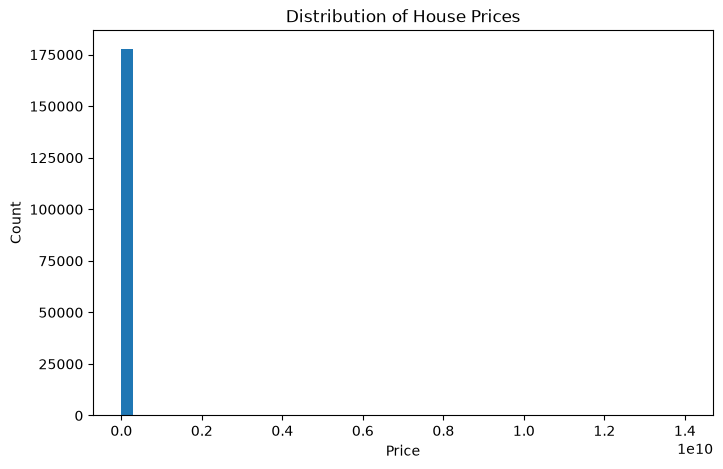

In [6]:
plt.figure(figsize=(8,5))
plt.hist(df["price_clean"], bins=50)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

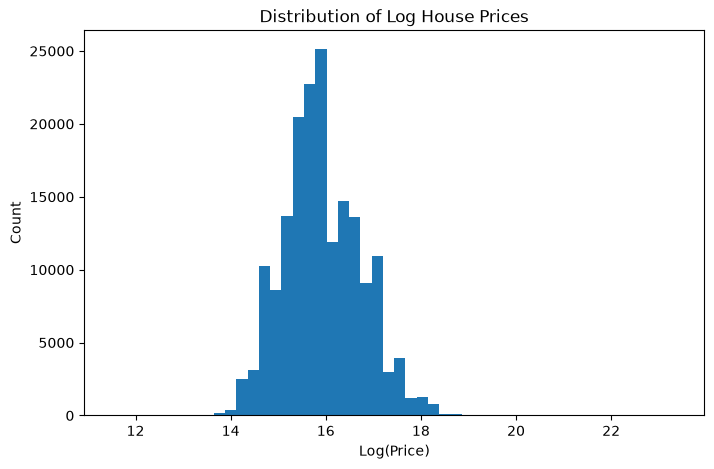

In [7]:
plt.figure(figsize=(8,5))
plt.hist(np.log1p(df["price_clean"]), bins=50)
plt.title("Distribution of Log House Prices")
plt.xlabel("Log(Price)")
plt.ylabel("Count")
plt.show()

In [8]:
df["carpet_area_sqft"] = (
    df["Carpet Area"]
    .str.extract(r'(\d+)')
    .astype(float)
)

In [9]:
df["floor_num"] = (
    df["Floor"]
    .str.extract(r'(\d+)')
    .astype(float)
)

In [10]:
df["Bathroom"] = (
    df["Bathroom"]
    .replace("> 10", "10")
    .astype(float)
)

In [11]:
df["Balcony"] = (
    df["Balcony"]
    .replace("> 10", "10")
    .astype(float)
)

In [12]:
location_counts = df["location"].value_counts()

df["location_grouped"] = df["location"].apply(
    lambda x: x if location_counts[x] >= 1500 else "other"
)

In [13]:
features = [
    "carpet_area_sqft",
    "floor_num",
    "Bathroom",
    "Balcony",
    "location_grouped",
    "Furnishing",
    "Transaction",
    "Ownership",
    "facing"
]

X = df[features]

y = np.log1p(df["price_clean"])

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
numeric_features = [
    "carpet_area_sqft",
    "floor_num",
    "Bathroom",
    "Balcony"
]

categorical_features = [
    "location_grouped",
    "Furnishing",
    "Transaction",
    "Ownership",
    "facing"
]

In [16]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [17]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [18]:
linear_model = Pipeline([
    ("prep", preprocessor),
    ("reg", LinearRegression())
])

In [19]:
linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['carpet_area_sqft','floor_num','Bathroom',...,'Transaction','Ownership', 'facing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columns

In [20]:
linear_pred = linear_model.predict(X_test)

In [21]:
print("Linear Regression")
print("MAE :", mean_absolute_error(y_test, linear_pred))
print("RMSE:", root_mean_squared_error(y_test, linear_pred))
print("R² :", r2_score(y_test, linear_pred))

Linear Regression
MAE : 0.3689525735735544
RMSE: 0.4835168756573812
R² : 0.6552148908252182


In [22]:
rf_model = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])


In [ ]:
rf_model.fit(X_train, y_train)

In [ ]:
rf_pred = rf_model.predict(X_test)

In [ ]:
print("Random Forest")
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE:", root_mean_squared_error(y_test, rf_pred))
print("R² :", r2_score(y_test, rf_pred))

Random Forest
MAE : 0.13231121869975043
RMSE: 0.2871306803280908
R² : 0.8784137600568249


In [ ]:
import joblib

joblib.dump(rf_model, "../backend/model.pkl")

['../backend/model.pkl']

In [ ]:
loaded_model = joblib.load("../backend/model.pkl")

print(type(loaded_model))

<class 'sklearn.pipeline.Pipeline'>
